In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

import torchvision
import torchvision.transforms as transforms
from torchvision import datasets

from torch.utils.data import DataLoader, WeightedRandomSampler

import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
import cv2

In [5]:
#Config
print("Setting up configuration...")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu") 
print(f"Using device: {device}")

# Define paths
ROOT = Path().resolve().parent
DATA_DIR = ROOT / 'data'

train_path = DATA_DIR /'train'
test_path = DATA_DIR / 'test'
val_path = DATA_DIR / 'val'

print(f"Train path: {train_path}")
print(f"Test path:  {test_path}")
print(f"Val path:   {val_path}")

BATCH_SIZE = 32

IMG_SIZE = 224
NUM_CLASSES = 2
MODEL_NAME = 'resnet18'

Setting up configuration...
Using device: cpu
Train path: C:\Users\andym\Projects\2025bioimagingBasics\01chestXrayClassification\chest-xray-classifier\data\train
Test path:  C:\Users\andym\Projects\2025bioimagingBasics\01chestXrayClassification\chest-xray-classifier\data\test
Val path:   C:\Users\andym\Projects\2025bioimagingBasics\01chestXrayClassification\chest-xray-classifier\data\val


In [6]:
#Load ResNet18

model = torchvision.models.resnet18(pretrained = False)
model.fc = nn.Linear(model.fc.in_features, NUM_CLASSES)
model = model.to(device)

print("\n Modified final layer:")
print(f"    Input features: {model.fc.in_features}")
print(f"    Output features: {model.fc.out_features}")


 Modified final layer:
    Input features: 512
    Output features: 2


c:\Users\andym\Projects\2025bioimagingBasics\01chestXrayClassification\chest-xray-classifier\venv\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\andym\Projects\2025bioimagingBasics\01chestXrayClassification\chest-xray-classifier\venv\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


In [7]:
#Data Setup

test_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

test_dataset = datasets.ImageFolder(
    root=test_path,
    transform=test_transforms
)


test_loader = DataLoader(
    test_dataset,
    BATCH_SIZE,
    shuffle=False,
)


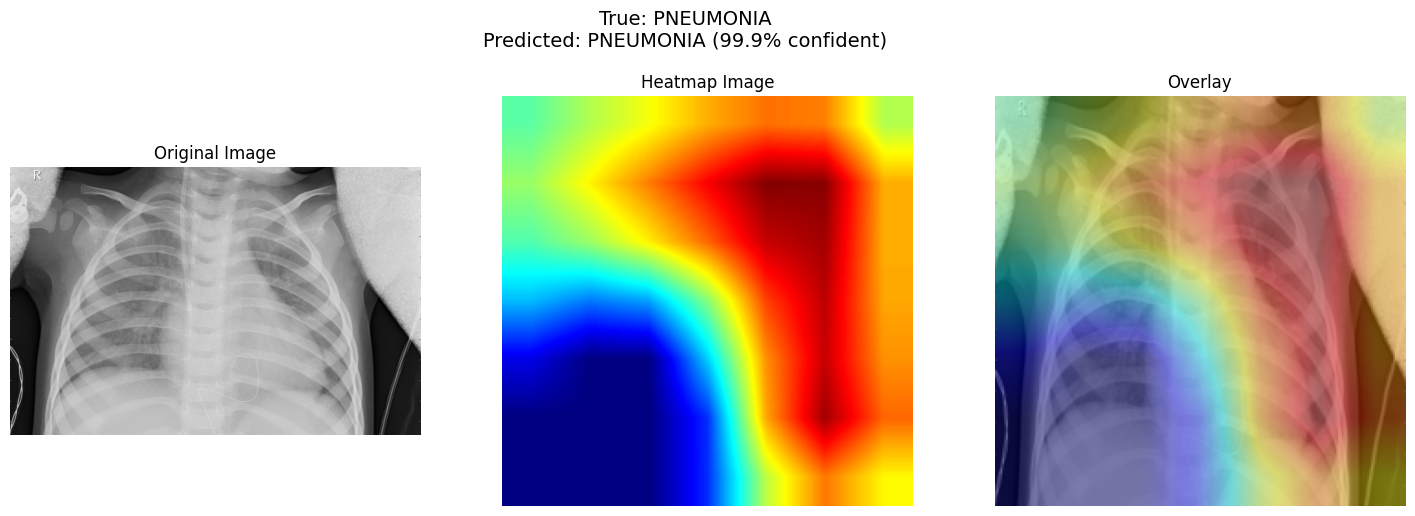

In [17]:
#Test Single Prediction

import random
from PIL import Image
model_path = ROOT / 'outputs' / 'models' / 'resnet18_pneumonia.pth'
model.load_state_dict(torch.load(model_path))
model = model.to(device)

model.eval()

class_names = ['NORMAL', 'PNEUMONIA']

test_normal = list((test_path / 'NORMAL').glob('*.jpeg'))
test_pneumonia = list((test_path / 'PNEUMONIA').glob('*.jpeg'))
all_test_images = test_normal + test_pneumonia

random_img_path = random.choice(all_test_images)

true_label = random_img_path.parent.name

img = Image.open(random_img_path).convert('RGB')
img_tensor = test_transforms(img)

img_tensor = img_tensor.unsqueeze(0)
img_tensor = img_tensor.to(device)

#Grad Cam var initialization 
activation = {}
gradients = {}

def forward_hook(module, input, output):
    activation['value'] = output.detach()

def backward_hook(module, grad_input, grad_output):
    gradients['value'] = grad_output[0].detach()

target_layer = model.layer4[-1]


fwd_handle = target_layer.register_forward_hook(forward_hook)
bwd_handle = target_layer.register_full_backward_hook(backward_hook)


with torch.set_grad_enabled(True):
    outputs = model(img_tensor)
    probabilities = torch.softmax(outputs, dim=1)
    confidence, predicted = torch.max(probabilities, 1)

    predicted_class = class_names[predicted.item()]
    confidence_percent = confidence.item() * 100
    target_class = predicted.item()
    score = outputs[0, target_class]
    model.zero_grad()
    score.backward()

weights = gradients['value'].mean(dim=(2, 3))
heatmap = (weights.unsqueeze(-1).unsqueeze(-1)*activation['value']).sum(dim=1)
heatmap = F.relu(heatmap)
heatmap = heatmap.squeeze()
heatmap = heatmap.cpu().numpy()
if heatmap.ndim == 3:
    heatmap = heatmap.mean(axis=-1)
heatmap = (heatmap - heatmap.min()) / (heatmap.max() - heatmap.min() + 1e-8)
heatmap_resized = cv2.resize(heatmap, (224, 224))
heatmap_resized = np.squeeze(heatmap_resized)

heatmap_colored = cv2.applyColorMap(np.uint8(255*heatmap_resized), cv2.COLORMAP_JET)
heatmap_colored = cv2.cvtColor(heatmap_colored, cv2.COLOR_BGR2RGB)

original_img_np = np.array(img.resize((224, 224)))
overlay = cv2.addWeighted(original_img_np, 0.6, heatmap_colored, 0.4, 0)


fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(18,6))


fig.suptitle(f"True: {true_label}\nPredicted: {predicted_class} ({confidence_percent:.1f}% confident)", 
          fontsize=14)
axes[0].imshow(img, cmap='gray')
axes[0].set_title("Original Image")
axes[0].axis('off')

axes[1].imshow(heatmap_colored, cmap='jet')
axes[1].set_title("Heatmap Image")
axes[1].axis('off')

axes[2].imshow(overlay)
axes[2].set_title("Overlay")
axes[2].axis('off')
plt.show()

fwd_handle.remove()
bwd_handle.remove()